# Phase 0: Exploratory Data Analysis (EDA)

Before building our data loaders or training the model, it is crucial to analyze our dataset characteristics. In this notebook, I will explore:
1. Class distribution (checking for data imbalance).
2. Image dimension distributions (to determine the best image resizing target).
3. Average color channel distributions across categories.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

# Define paths
data_dir = "../data/"
categories = ["with_mask", "without_mask"]

# Gather metadata about every image
image_data = []

for category in categories:
    folder_path = os.path.join(data_dir, category)
    if not os.path.exists(folder_path):
        continue
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                # Convert to numpy array to compute mean color channels
                img_array = np.array(img.convert('RGB'))
                r_mean = img_array[:, :, 0].mean()
                g_mean = img_array[:, :, 1].mean()
                b_mean = img_array[:, :, 2].mean()
                
                image_data.append({
                    "filename": img_name,
                    "category": category,
                    "width": width,
                    "height": height,
                    "r_mean": r_mean,
                    "g_mean": g_mean,
                    "b_mean": b_mean
                })
        except Exception as e:
            # Skip corrupted or non-image files if any
            continue

df = pd.DataFrame(image_data)
print(f"Dataset summary compiled! Total images found: {len(df)}")
df.head()

f:\SLIIT\_Year_03_\Semester 01\_ Self Study _\Face-Mask-Detector\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Dataset summary compiled! Total images found: 7553


,filename,category,width,height,r_mean,g_mean,b_mean
0,with_mask_1.jpg,with_mask,525,350,67.081459,66.709540,54.485932
1,with_mask_10.jpg,with_mask,135,218,131.446415,94.394088,58.128508
2,with_mask_100.jpg,with_mask,86,105,104.030454,77.556589,59.500664
3,with_mask_1000.jpg,with_mask,310,403,105.424093,101.465997,91.817186
4,with_mask_1001.jpg,with_mask,121,204,139.196808,113.813563,106.766124


## 1. Class Distribution Analysis

Let's check if our dataset is balanced or heavily skewed toward one class. Severely imbalanced datasets can bias the model's predictions.

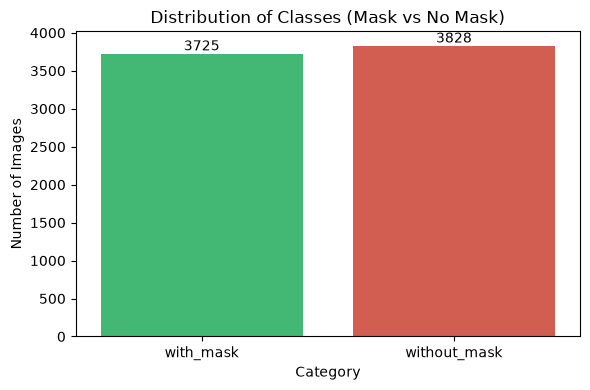

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='category', hue='category', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribution of Classes (Mask vs No Mask)')
plt.xlabel('Category')
plt.ylabel('Number of Images')

# Add value labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 2. Image Dimensions Analysis

Images in raw datasets often come in various shapes and aspect ratios. Analyzing heights and widths helps justify why we resize our inputs to $224 \times 224$ pixels for MobileNetV2.

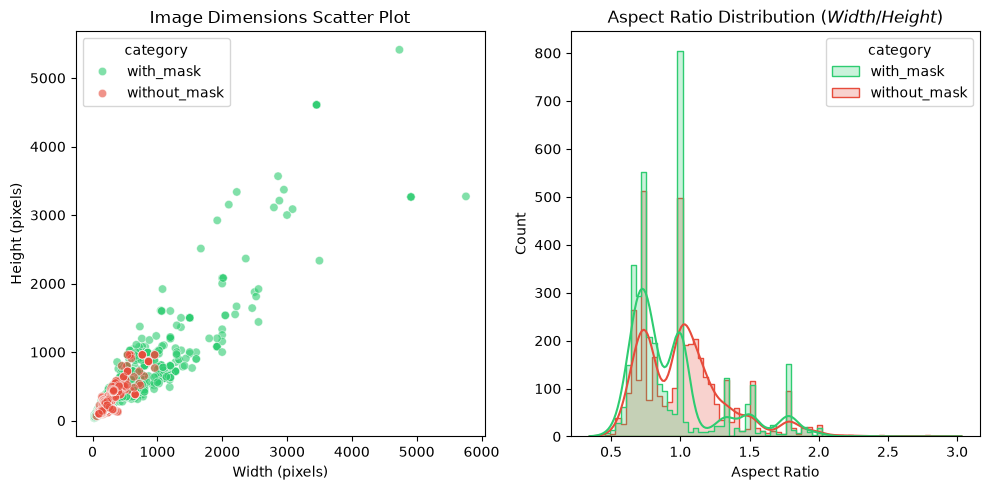

In [4]:
plt.figure(figsize=(10, 5))

# Scatter plot of Width vs Height
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='width', y='height', hue='category', alpha=0.6, palette=['#2ecc71', '#e74c3c'])
plt.title('Image Dimensions Scatter Plot')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')

# Distribution of Aspect Ratios
plt.subplot(1, 2, 2)
df['aspect_ratio'] = df['width'] / df['height']
sns.histplot(data=df, x='aspect_ratio', hue='category', kde=True, element='step', palette=['#2ecc71', '#e74c3c'])
plt.title('Aspect Ratio Distribution ($Width / Height$)')
plt.xlabel('Aspect Ratio')

plt.tight_layout()
plt.show()

## 3. Color Channel Intensity Profiling

Let's see if there is a distinct difference in the average color palettes between people wearing masks and those who aren't. Surgical masks often introduce a lot of bright blue/white hues.

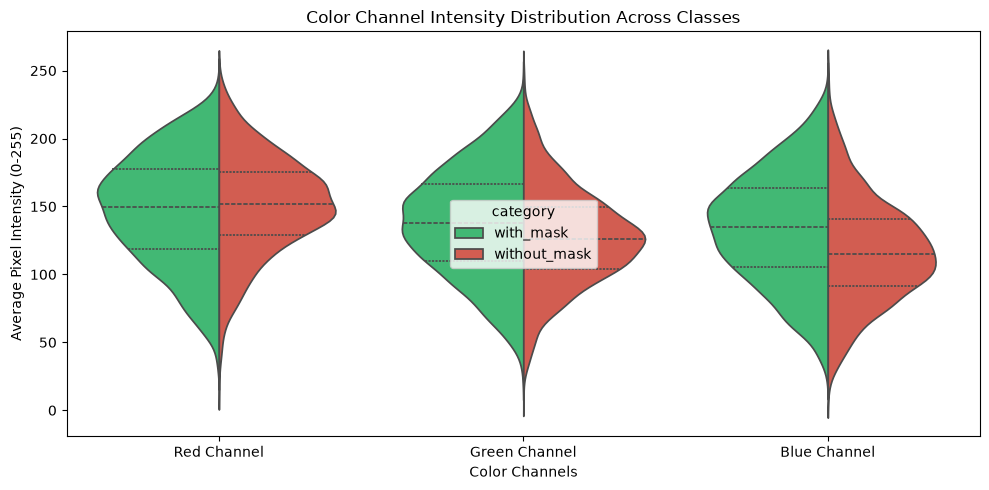

In [5]:
# Melt the dataframe to make it suitable for a violin plot comparison
color_df = df.melt(id_vars=['category'], value_vars=['r_mean', 'g_mean', 'b_mean'], 
                  var_name='Channel', value_name='Intensity')

plt.figure(figsize=(10, 5))
sns.violinplot(data=color_df, x='Channel', y='Intensity', hue='category', split=True, inner='quart', palette=['#2ecc71', '#e74c3c'])
plt.title('Color Channel Intensity Distribution Across Classes')
plt.xticks([0, 1, 2], ['Red Channel', 'Green Channel', 'Blue Channel'])
plt.xlabel('Color Channels')
plt.ylabel('Average Pixel Intensity (0-255)')
plt.tight_layout()
plt.show()

## 4. Image Brightness (Luminance) Distribution

Lighting conditions can drastically affect a computer vision model's performance. If all "With Mask" images are bright (e.g., taken in hospitals) and "Without Mask" images are dark, the model might accidentally learn to predict lighting instead of masks. 

I will calculate the perceived brightness (luminance) using the standard formula: $Y = 0.299R + 0.587G + 0.114B$ using the mean color channels I already extracted.

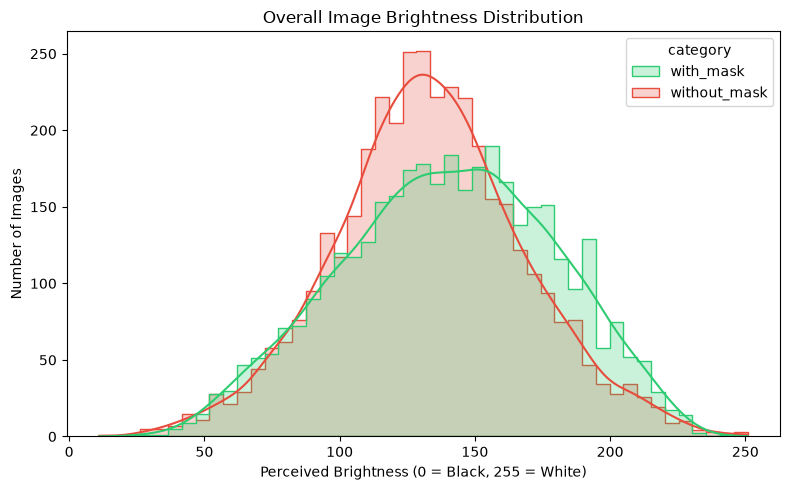

In [6]:
# Calculate perceived brightness for each image
df['brightness'] = 0.299 * df['r_mean'] + 0.587 * df['g_mean'] + 0.114 * df['b_mean']

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='brightness', hue='category', kde=True, element='step', palette=['#2ecc71', '#e74c3c'])
plt.title('Overall Image Brightness Distribution')
plt.xlabel('Perceived Brightness (0 = Black, 255 = White)')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

## 5. The "Average" Face

What does the "average" image of each class look like? By resizing a sample of images from each class to the exact same dimensions and mathematically averaging their pixel values, I can see spatial biases. For example, it will show if faces are generally centered, and it should reveal a blurred mask shape in the "With Mask" category.

*Note: I am using a random sample of 300 images per class to keep memory usage low.*

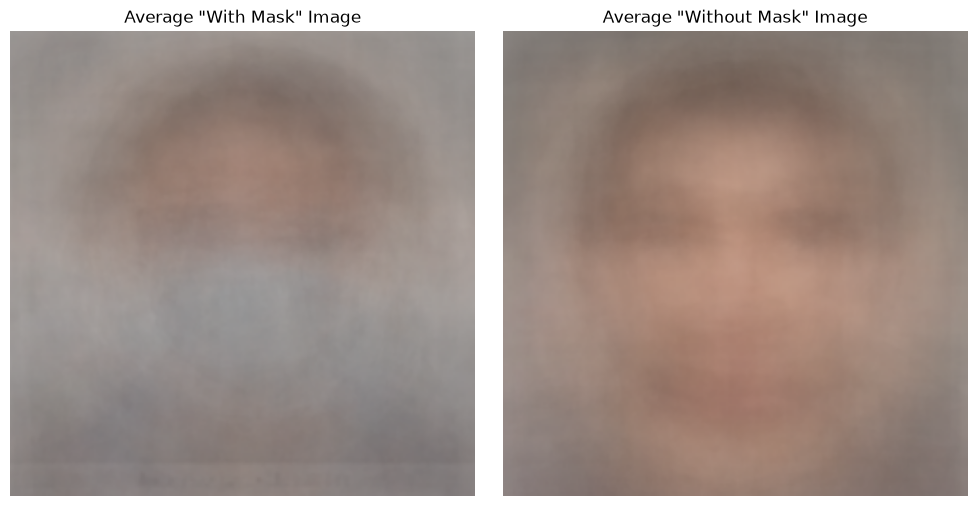

In [7]:
import random

def get_average_image(category, sample_size=300, target_size=(224, 224)):
    folder_path = os.path.join(data_dir, category)
    image_files = os.listdir(folder_path)
    
    # Take a random sample to save memory
    sample_files = random.sample(image_files, min(sample_size, len(image_files)))
    
    # Initialize a tensor of zeros to hold the sum of all images
    avg_img_array = np.zeros((target_size[1], target_size[0], 3), dtype=np.float64)
    valid_images = 0
    
    for img_name in sample_files:
        img_path = os.path.join(folder_path, img_name)
        try:
            with Image.open(img_path) as img:
                img = img.resize(target_size).convert('RGB')
                avg_img_array += np.array(img, dtype=np.float64)
                valid_images += 1
        except:
            continue
            
    # Divide by the number of images to get the average, and convert back to 8-bit integers
    avg_img_array = (avg_img_array / valid_images).astype(np.uint8)
    return avg_img_array

# Generate the average images
avg_with_mask = get_average_image("with_mask")
avg_without_mask = get_average_image("without_mask")

# Plot them side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(avg_with_mask)
axes[0].set_title('Average "With Mask" Image')
axes[0].axis('off')

axes[1].imshow(avg_without_mask)
axes[1].set_title('Average "Without Mask" Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Image Complexity (Edge Density)

Do masks make an image more "complex"? Surgical masks often introduce sharp straight lines across the face. By using OpenCV's Canny Edge Detection, I can calculate the percentage of "edge pixels" in an image to see if masked faces consistently trigger higher edge densities than unmasked faces.

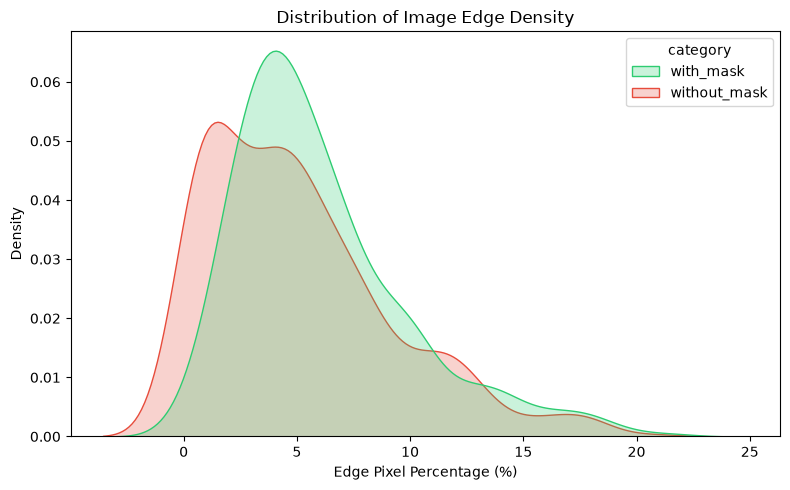

In [8]:
import cv2

def calculate_edge_density(image_path):
    # Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    # Resize to standardize
    img = cv2.resize(img, (224, 224))
    # Apply Canny edge detection
    edges = cv2.Canny(img, 100, 200)
    # Calculate percentage of edge pixels
    density = (np.sum(edges > 0) / edges.size) * 100
    return density

# Sample a subset of data for quicker processing
sample_df = df.groupby('category').sample(n=500, random_state=42)
edge_densities = []

for idx, row in sample_df.iterrows():
    img_path = os.path.join(data_dir, row['category'], row['filename'])
    density = calculate_edge_density(img_path)
    edge_densities.append(density)

sample_df['edge_density'] = edge_densities

plt.figure(figsize=(8, 5))
sns.kdeplot(data=sample_df, x='edge_density', hue='category', fill=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Image Edge Density')
plt.xlabel('Edge Pixel Percentage (%)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## 7. Dimensionality Reduction (PCA Clustering)

Can a simpler algorithm tell these images apart? Principal Component Analysis (PCA) is a mathematical technique that takes our highly complex images (224x224x3 = 150,528 dimensions) and squashes them down into just 2 dimensions, preserving as much variance as possible. If we plot these 2D points, we can see if the "Mask" and "No Mask" classes naturally form separate clusters!

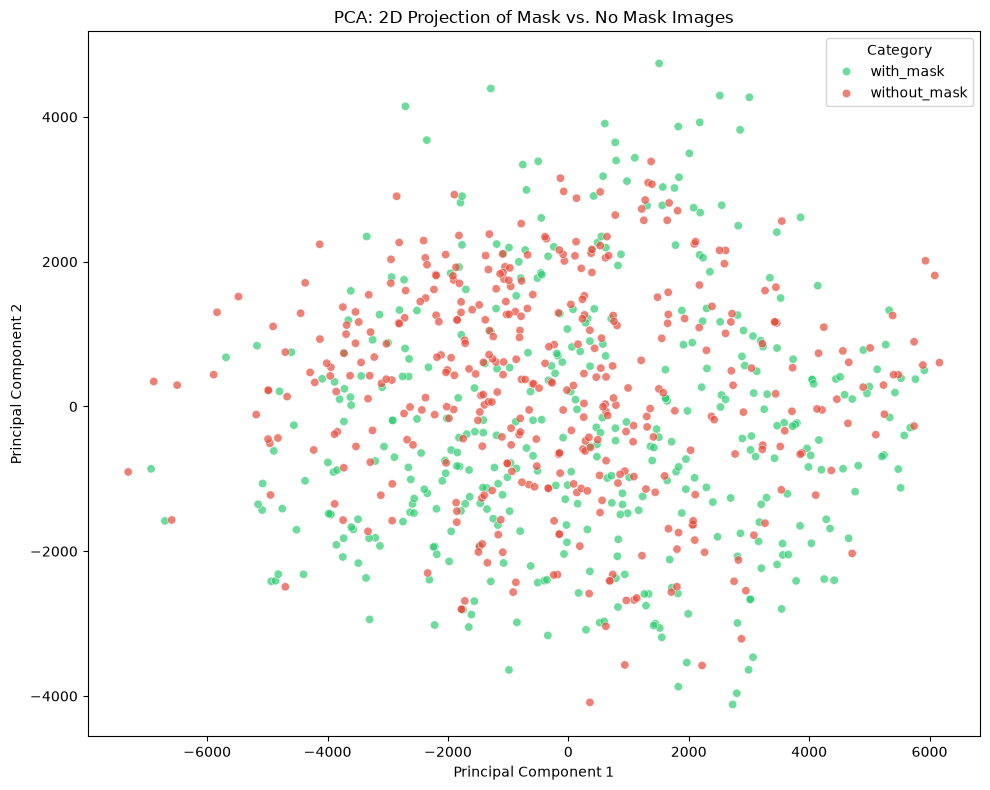

In [9]:
from sklearn.decomposition import PCA

# We will use a smaller sample so we don't crash our memory
pca_sample_size = 400 
flat_images = []
labels = []

for category in categories:
    folder_path = os.path.join(data_dir, category)
    image_files = random.sample(os.listdir(folder_path), pca_sample_size)
    
    for img_name in image_files:
        img_path = os.path.join(folder_path, img_name)
        try:
            with Image.open(img_path) as img:
                # Resize extremely small to make PCA computationally feasible
                img = img.resize((64, 64)).convert('L') # Convert to grayscale
                img_array = np.array(img).flatten() # Flatten to 1D array (4096 pixels)
                flat_images.append(img_array)
                labels.append(category)
        except:
            continue

# Stack the arrays
X = np.vstack(flat_images)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'Principal Component 1': X_pca[:, 0],
    'Principal Component 2': X_pca[:, 1],
    'Category': labels
})

# Plot the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='Principal Component 1', y='Principal Component 2', 
                hue='Category', alpha=0.7, palette=['#2ecc71', '#e74c3c'])
plt.title('PCA: 2D Projection of Mask vs. No Mask Images')
plt.tight_layout()
plt.show()

## 8. Non-Linear Dimensionality Reduction (t-SNE)

Since PCA (a linear algorithm) struggled to perfectly separate the mask and no-mask images, let's try t-SNE (t-Distributed Stochastic Neighbor Embedding). t-SNE is a non-linear technique specifically designed for visualizing high-dimensional data like images. It groups similar images closer together and pushes dissimilar ones apart.

*Note: I will reuse the flattened image array (`X`) and `labels` from the PCA step.*

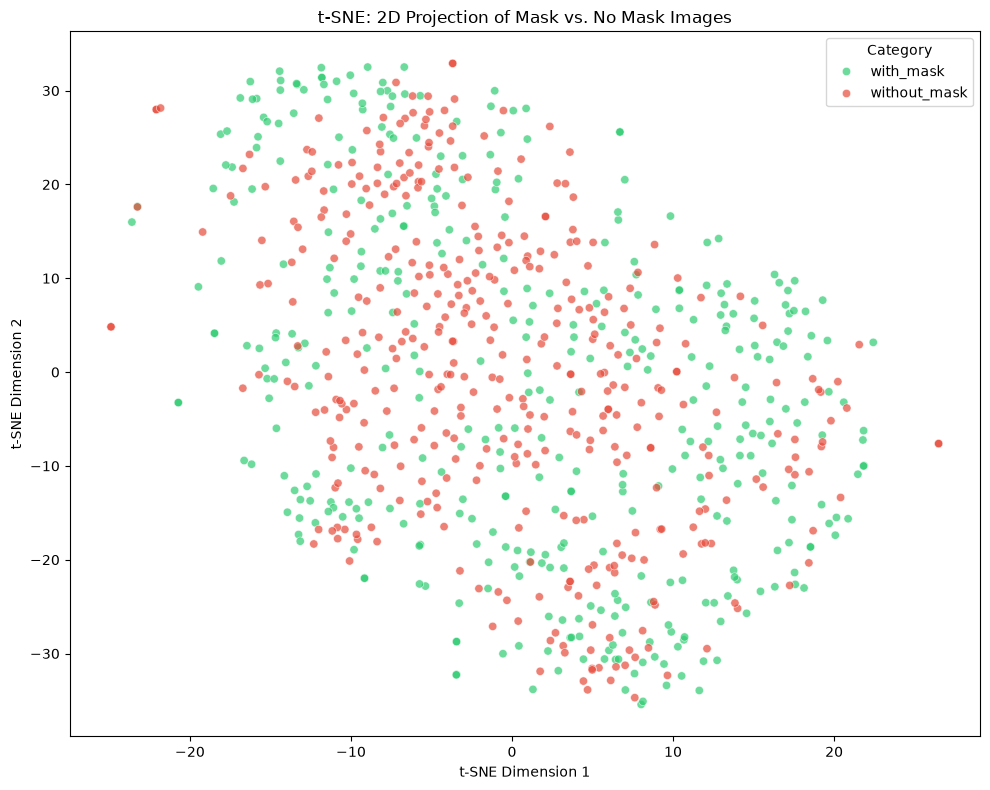

In [10]:
from sklearn.manifold import TSNE

# Initialize t-SNE
# Perplexity is a tuneable parameter, usually between 5 and 50.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

# Fit and transform the flattened images
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame({
    't-SNE Dimension 1': X_tsne[:, 0],
    't-SNE Dimension 2': X_tsne[:, 1],
    'Category': labels
})

# Plot the t-SNE clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='t-SNE Dimension 1', y='t-SNE Dimension 2', 
                hue='Category', alpha=0.7, palette=['#2ecc71', '#e74c3c'])
plt.title('t-SNE: 2D Projection of Mask vs. No Mask Images')
plt.tight_layout()
plt.show()

## 9. Visualizing the "Eigenfaces"

What exactly did PCA learn when it compressed our images? By taking the principal components (the axes of maximum variance) and reshaping them back into 64x64 pixel grids, we can visualize the "Eigenfaces." These ghostly images represent the core spatial patterns that explain the most variation in the dataset.

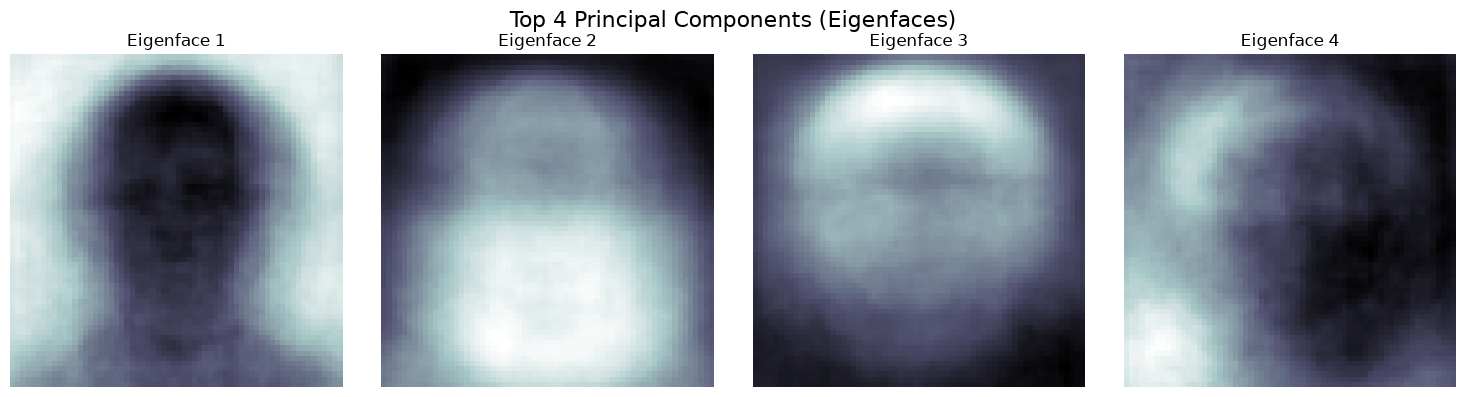

In [11]:
# Re-run PCA but keep the top 4 components to visualize them
pca_faces = PCA(n_components=4, random_state=42)
pca_faces.fit(X)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i, ax in enumerate(axes):
    # Reshape the 4096-length component vector back into a 64x64 image
    eigenface = pca_faces.components_[i].reshape(64, 64)
    
    # We use the 'bone' colormap as it shows grayscale variance well
    ax.imshow(eigenface, cmap='bone')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')

plt.suptitle('Top 4 Principal Components (Eigenfaces)', fontsize=16)
plt.tight_layout()
plt.show()